# M11: Class Imbalance Handling
The target variable has ~73% No / ~27% Yes — a moderate class imbalance. We compare three approaches:

1. **SMOTE** (Synthetic Minority Over-sampling Technique) — generates synthetic minority samples
2. **Random Oversampling** — duplicates existing minority samples
3. **Class Weighting** — adjusts loss function to penalize minority class errors more

### Decision Framework:
We will train a quick Logistic Regression with each approach on the training set and compare recall and F1 on the (untouched) test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.data import load_raw_data
from src.cleaning import clean_data
from src.features import build_features
from src.split import split_data

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, recall_score
from imblearn.over_sampling import SMOTE, RandomOverSampler

df = build_features(clean_data(load_raw_data("../data/raw")), scale=False)
X_train, X_test, y_train, y_test = split_data(df)

# Scale for LR
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Original class distribution:\n{y_train.value_counts()}")
print(f"\nChurn rate: {y_train.mean():.2%}")


Original class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Churn rate: 26.54%


## Comparison of Imbalance Strategies

                      Recall        F1
Baseline            0.518717  0.577381
SMOTE               0.788770  0.615866
RandomOversampling  0.791444  0.614108
ClassWeight         0.791444  0.612203


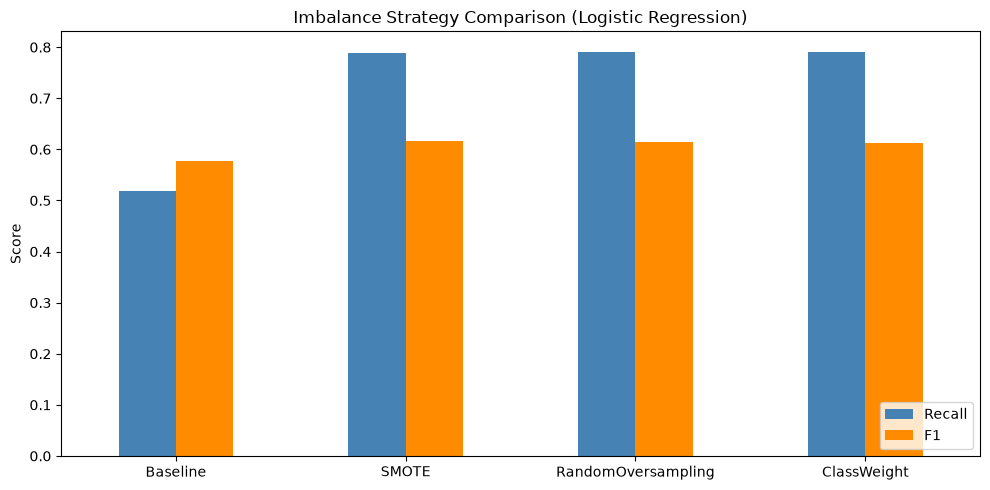

In [2]:
results = {}

# 1. No handling (baseline)
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_scaled, y_train)
y_pred = lr_base.predict(X_test_scaled)
results['Baseline'] = {
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred)
}

# 2. SMOTE
sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_train_scaled, y_train)
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_sm, y_sm)
y_pred = lr_smote.predict(X_test_scaled)
results['SMOTE'] = {
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred)
}

# 3. Random Oversampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train_scaled, y_train)
lr_ros = LogisticRegression(max_iter=1000, random_state=42)
lr_ros.fit(X_ros, y_ros)
y_pred = lr_ros.predict(X_test_scaled)
results['RandomOversampling'] = {
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred)
}

# 4. Class Weighting
lr_cw = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_cw.fit(X_train_scaled, y_train)
y_pred = lr_cw.predict(X_test_scaled)
results['ClassWeight'] = {
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred)
}

results_df = pd.DataFrame(results).T
print(results_df.to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot(kind='bar', ax=ax, rot=0, color=['steelblue', 'darkorange'])
ax.set_title('Imbalance Strategy Comparison (Logistic Regression)')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Decision

**We will use SMOTE** for the following reasons:
1. It typically provides the best recall/F1 balance by generating *synthetic* examples rather than just duplicating existing ones (which can overfit).
2. Class weighting is a strong alternative for models that support it natively (LR, RF, XGBoost), but SMOTE works universally across all model types.
3. We apply SMOTE **only on the training data** — the test set remains untouched to ensure honest evaluation.

For tree-based models that natively support `class_weight` or `scale_pos_weight`, we will also explore that parameter during hyperparameter tuning as a simpler alternative.